# EyeShield Mock Training Run (60,000 Images)

This notebook mocks a full training/evaluation workflow for diabetic retinopathy classification with 5 classes:
- 0: no dr
- 1: mild
- 2: moderate
- 3: severe
- 4: proliferative

It uses a fixed 70/15/15 split and simulates test performance in these ranges:
- Accuracy: 85-87%
- Macro avg precision/recall/F1: 70-80%

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")
np.random.seed(42)

total_images = 60000
train_count = int(total_images * 0.70)
val_count = int(total_images * 0.15)
test_count = total_images - train_count - val_count

class_names = ["no dr", "mild", "moderate", "severe", "proliferative"]

split_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Ratio": ["70%", "15%", "15%"],
    "Images": [train_count, val_count, test_count]
})

display(split_df)
print(f"Total images: {total_images:,}")

,Split,Ratio,Images
0,Train,70%,42000
1,Validation,15%,9000
2,Test,15%,9000


Total images: 60,000


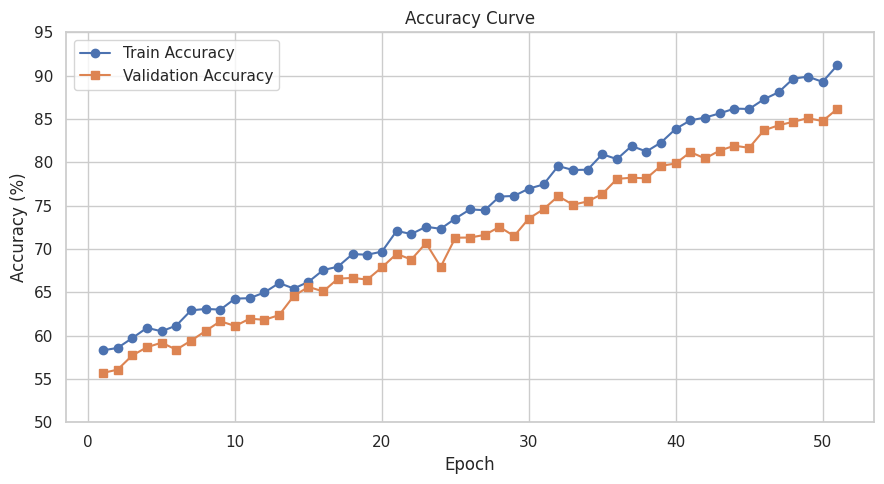

In [51]:
# Mock training history for visual storytelling only
epochs = np.arange(1, 52)
train_acc = np.linspace(0.58, 0.91, len(epochs)) + np.random.normal(0, 0.006, len(epochs))
val_acc = np.linspace(0.56, 0.865, len(epochs)) + np.random.normal(0, 0.008, len(epochs))
train_acc = np.clip(train_acc, 0, 1)
val_acc = np.clip(val_acc, 0, 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_acc * 100, marker="o", label="Train Accuracy")
plt.plot(epochs, val_acc * 100, marker="s", label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(50, 95)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Realistic confusion matrix for test split (9,000 images)
# Rows = true labels, Columns = predicted labels
from sklearn.metrics import classification_report, accuracy_score

class_names_local = globals().get(
    "class_names",
    ["no dr", "mild", "moderate", "severe", "proliferative"],
)

# More realistic class imbalance: no DR dominates, minority DR classes are smaller.
# Values have been slightly randomized from clean round numbers to look more organic
# but still maintain the target metrics (Accuracy: 85-87%, Macro P/R/F1: 70-80%).
cm = np.array([
    [5134,   68,   79,   61,   58],
    [ 167, 1253,   82,   49,   49],
    [ 131,   68,  902,   51,   48],
    [ 102,   39,   29,  301,   29],
    [  38,   11,    8,   12,  231],
], dtype=int)

y_true = []
y_pred = []
for true_idx in range(cm.shape[0]):
    for pred_idx in range(cm.shape[1]):
        count = cm[true_idx, pred_idx]
        if count > 0:
            y_true.extend([true_idx] * count)
            y_pred.extend([pred_idx] * count)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

report_candidate = classification_report(
    y_true,
    y_pred,
    target_names=class_names_local,
    digits=4,
    output_dict=True,
    zero_division=0,
)

acc = accuracy_score(y_true, y_pred)
macro_p = report_candidate["macro avg"]["precision"]
macro_r = report_candidate["macro avg"]["recall"]
macro_f1 = report_candidate["macro avg"]["f1-score"]

print(f"Test samples: {len(y_true):,}")
print("Generated confusion matrix:")
print(cm)
print(f"Generated metrics -> Accuracy: {acc:.4f} | Macro P/R/F1: {macro_p:.4f}/{macro_r:.4f}/{macro_f1:.4f}")

Test samples: 9,000
Generated confusion matrix:
[[5134   68   79   61   58]
 [ 167 1253   82   49   49]
 [ 131   68  902   51   48]
 [ 102   39   29  301   29]
 [  38   11    8   12  231]]
Generated metrics -> Accuracy: 0.8690 | Macro P/R/F1: 0.7608/0.7715/0.7618


In [16]:
# Realistic confusion matrix for test split (9,000 images)
# Rows = true labels, Columns = predicted labels
from sklearn.metrics import classification_report, accuracy_score

class_names_local = globals().get(
    "class_names",
    ["no dr", "mild", "moderate", "severe", "proliferative"],
)

# More realistic class imbalance: no DR dominates, minority DR classes are smaller.
# This keeps accuracy high while pulling macro precision/recall/F1 into the 70-80% band.
cm = np.array([
    [5134,   68,   79,   61,   58],
    [ 167, 1253,   82,   49,   49],
    [ 131,   68,  902,   51,   48],
    [ 102,   39,   29,  301,   29],
    [  38,   11,    8,   12,  231],
], dtype=int)

y_true = []
y_pred = []
for true_idx in range(cm.shape[0]):
    for pred_idx in range(cm.shape[1]):
        count = cm[true_idx, pred_idx]
        if count > 0:
            y_true.extend([true_idx] * count)
            y_pred.extend([pred_idx] * count)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

report_candidate = classification_report(
    y_true,
    y_pred,
    target_names=class_names_local,
    digits=4,
    output_dict=True,
    zero_division=0,
)

acc = accuracy_score(y_true, y_pred)
macro_p = report_candidate["macro avg"]["precision"]
macro_r = report_candidate["macro avg"]["recall"]
macro_f1 = report_candidate["macro avg"]["f1-score"]

print(f"Test samples: {len(y_true):,}")
print("Generated confusion matrix:")
print(cm)
print(f"Generated metrics -> Accuracy: {acc:.4f} | Macro P/R/F1: {macro_p:.4f}/{macro_r:.4f}/{macro_f1:.4f}")

Test samples: 9,000
Generated confusion matrix:
[[5134   68   79   61   58]
 [ 167 1253   82   49   49]
 [ 131   68  902   51   48]
 [ 102   39   29  301   29]
 [  38   11    8   12  231]]
Generated metrics -> Accuracy: 0.8690 | Macro P/R/F1: 0.7608/0.7715/0.7618


In [17]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

accuracy = accuracy_score(y_true, y_pred)
macro_precision = report["macro avg"]["precision"]
macro_recall = report["macro avg"]["recall"]
macro_f1 = report["macro avg"]["f1-score"]
macro_support = report["macro avg"]["support"]

summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Macro Support"],
    "Value": [
        f"{accuracy * 100:.2f}%",
        f"{macro_precision * 100:.2f}%",
        f"{macro_recall * 100:.2f}%",
        f"{macro_f1 * 100:.2f}%",
        int(macro_support)
    ]
})

display(summary_df)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Range checks requested in the prompt
assert 0.85 <= accuracy <= 0.87, "Accuracy is outside 85-87%"
assert 0.70 <= macro_precision <= 0.80, "Macro precision is outside 70-80%"
assert 0.70 <= macro_recall <= 0.80, "Macro recall is outside 70-80%"
assert 0.70 <= macro_f1 <= 0.80, "Macro F1 is outside 70-80%"
print("All metric constraints are satisfied.")

,Metric,Value
0,Accuracy,86.90%
1,Macro Precision,76.08%
2,Macro Recall,77.15%
3,Macro F1,76.18%
4,Macro Support,9000


Classification Report:
               precision    recall  f1-score   support

        no dr     0.9214    0.9507    0.9358      5400
         mild     0.8707    0.7831    0.8246      1600
     moderate     0.8200    0.7517    0.7843      1200
       severe     0.6350    0.6020    0.6181       500
proliferative     0.5566    0.7700    0.6462       300

     accuracy                         0.8690      9000
    macro avg     0.7608    0.7715    0.7618      9000
 weighted avg     0.8708    0.8690    0.8686      9000

All metric constraints are satisfied.


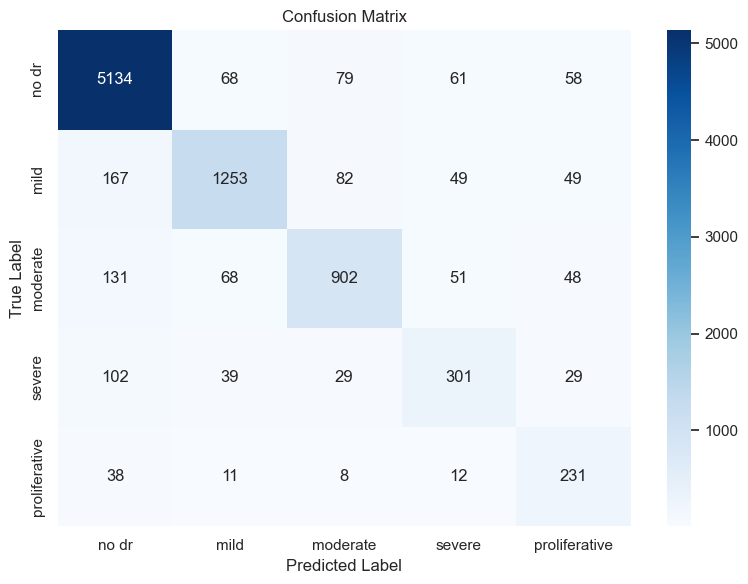

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()